**1. Bitcoin wallet exploit (3 point)**

* Calculate the probability of generating an already used private key in the Bitcoin network, given that a total of \(10^8\) keys are in use. Give the formula and numerical results
* Verify your result experimentally on scaled-down versions of secp256k1. Here \(b\) denotes the bit length of the group order \(n\), so $(n ≈ 2^b)$. The real secp256k1 has \(b = 256\). For $(b = 20, 24, \dots , 40)$, find a prime \(p\) such that \(y^2 = x^3 + 7\) over $(\mathbb{F}_p)$ has a prime number of points \(n\) with \(b\) bits. Choose a population size \(N < n\), measure how often a newly generated key matches one of the \(N\) existing ones, and compare with your formula. Plot $(\log_2 P)$ against \(b\) and extrapolate to $(b = 256)$.



$$
P = \frac{N}{n} \approx \frac{10^8}{2^{256}} \approx {10^{-69}}
$$

b=20: p=1048583, N=2000, expected_hits=190733.6, P_exp=3.829e-03, P_theory=3.815e-03
b=24: p=16777259, N=2000, expected_hits=11920.9, P_exp=2.373e-04, P_theory=2.384e-04
b=28: p=268435459, N=2000, expected_hits=745.1, P_exp=1.558e-05, P_theory=1.490e-05
b=32: p=4294967311, N=2000, expected_hits=46.6, P_exp=9.200e-07, P_theory=9.313e-07
b=36: p=68719476767, N=2000, expected_hits=2.9, P_exp=8.000e-08, P_theory=5.821e-08
b=40: p=1099511627791, N=2000, expected_hits=0.2, P_exp=4.000e-08, P_theory=3.638e-09


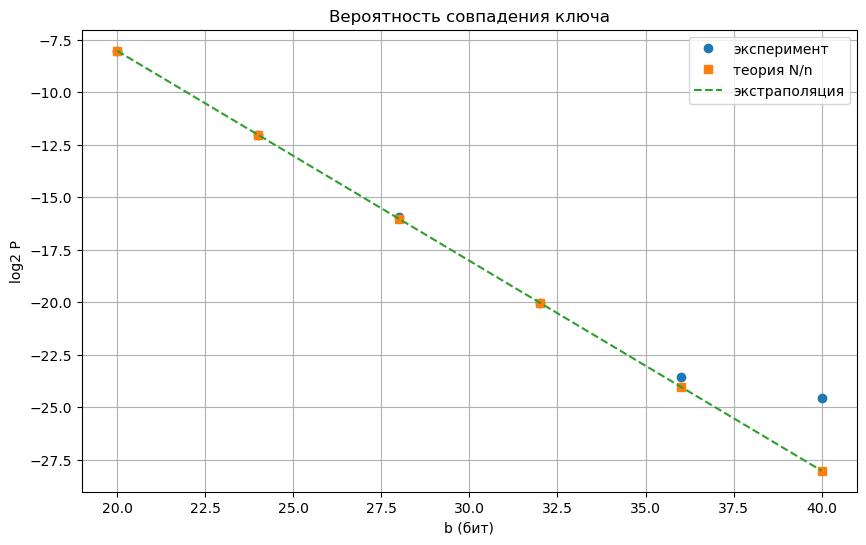


Экстраполяция для b = 40:
  log2 P = -28.03
  P ~ 2^-28.03 = 3.638e-09


In [44]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from sympy import nextprime

# ---------------------------------------------------------------
# Кривая y^2 = x^3 + 7 mod p (используется только x-координата).
# По теореме Хассе #E(F_p) = p + 1 - t, |t| <= 2*sqrt(p),
# поэтому для оценки вероятности по порядку величины берём n ~ p
# и не считаем точное число точек (это O(p) и програмно сложно реализуемо при b >= 32).
# ---------------------------------------------------------------

def random_x(p):
    """Случайный x, для которого x^3+7 mod p — квадратичный вычет (т.е. существует точка с этим x)."""
    while True:
        x = random.randrange(p)
        rhs = (x**3 + 7) % p
        if rhs == 0 or pow(rhs, (p - 1) // 2, p) == 1:
            return x

def collision_probability(p, N, num_trials=20000):
    """Доля попаданий нового x в уже сгенерированную популяцию размера N."""
    population = {random_x(p) for _ in range(N)}
    hits = sum(random_x(p) in population for _ in range(num_trials))
    return hits / num_trials


def run_all(b_values, N=2000, num_trials=50000000):
    results = []
    for b in b_values:
        p = nextprime(2 ** b)
        n = p / 2
        p_exp = collision_probability(p, N, num_trials)
        p_theory = N / n
        expected_hits = num_trials * p_theory
        print(f"b={b}: p={p}, N={N}, expected_hits={expected_hits:.1f}, "
              f"P_exp={p_exp:.3e}, P_theory={p_theory:.3e}")
        results.append((b, p_exp, p_theory))
    return results


def plot_results(results, target_b=40):
    bs, p_exp, p_theory = zip(*results)
    log_exp = [math.log2(v) if v > 0 else None for v in p_exp]
    log_theory = [math.log2(v) for v in p_theory]

    slope, intercept = np.polyfit(bs, log_theory, 1)
    b_ext = np.arange(min(bs), target_b + 1, 4)
    log_ext = slope * b_ext + intercept

    plt.figure(figsize=(10, 6))
    bs_e = [b for b, v in zip(bs, log_exp) if v is not None]
    log_e = [v for v in log_exp if v is not None]
    plt.plot(bs_e, log_e, 'o', label='эксперимент')
    plt.plot(bs, log_theory, 's', label='теория N/n')
    plt.plot(b_ext, log_ext, '--', label='экстраполяция')
    plt.xlabel('b (бит)')
    plt.ylabel('log2 P')
    plt.title('Вероятность совпадения ключа')
    plt.legend()
    plt.grid(True)
    plt.savefig('probability.png', dpi=120)
    plt.show()

    logP = slope * target_b + intercept
    print(f"\nЭкстраполяция для b = {target_b}:")
    print(f"  log2 P = {logP:.2f}")
    print(f"  P ~ 2^{logP:.2f} = {2 ** logP:.3e}")


results = run_all([20, 24, 28, 32, 36, 40])
plot_results(results)

> **2. Implement your own hash function in Python (3 points)**
> 
> * Demonstrate the properties of a hash function on your input data:
> * determinism
> * computation speed
> * avalanche effect
> * uniformity
> * chi squared
> * collisions
> * bit balances
> 
> Describe the advantages and disadvantages of your hash function based on benchmark results.

In [ ]:
import os
import time
import random
from collections import Counter
from scipy.stats import chisquare

MASK64 = (1 << 64) - 1
PRIME1 = 0x9E3779B185EBCA87
PRIME2 = 0xC2B2AE3D27D4EB4F


def simple_hash(data: bytes, seed: int = 0, out_bits: int = 64) -> int:
    """
    Простая непотоковая хэш-функция.
    На каждом байте состояние h перемешивается XOR-ом байта,
    умножением на большую нечётную константу и сдвигом-XOR-ом.
    В конце — дополнительный финализатор для усиления лавинного эффекта.
    """
    h = (seed ^ PRIME1) & MASK64
    for b in data:
        h = (h ^ b) & MASK64
        h = (h * PRIME2) & MASK64
        h ^= h >> 29

    h ^= h >> 33
    h = (h * PRIME1) & MASK64
    h ^= h >> 29
    h = (h * PRIME2) & MASK64
    h ^= h >> 32

    if out_bits < 64:
        h &= (1 << out_bits) - 1
    return h


def random_bytes(n_bytes):
    return os.urandom(n_bytes)

# 1. Детерминированность

def test_determinism(n_samples=1000, data_len=32):
    ok = True
    for _ in range(n_samples):
        data = random_bytes(data_len)
        if simple_hash(data) != simple_hash(data):
            ok = False
            break
    return ok

# 2. Скорость вычисления


def test_speed(n_samples=20000, data_len=64):
    data_list = [random_bytes(data_len) for _ in range(n_samples)]
    t0 = time.perf_counter()
    for d in data_list:
        simple_hash(d)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    hashes_per_sec = n_samples / elapsed
    mb_per_sec = (n_samples * data_len) / elapsed / (1024 * 1024)
    return elapsed, hashes_per_sec, mb_per_sec

# 3. Лавинный эффект: доля изменившихся бит при инверсии 1 бита входа

def test_avalanche(n_samples=2000, data_len=32, out_bits=64):
    total_frac = 0.0
    for _ in range(n_samples):
        data = bytearray(random_bytes(data_len))
        h1 = simple_hash(bytes(data), out_bits=out_bits)

        bit_pos = random.randrange(data_len * 8)
        byte_idx, bit_idx = divmod(bit_pos, 8)
        data[byte_idx] ^= (1 << bit_idx)
        h2 = simple_hash(bytes(data), out_bits=out_bits)

        diff_bits = bin(h1 ^ h2).count('1')
        total_frac += diff_bits / out_bits
    return total_frac / n_samples

# 4. Равномерность распределения по корзинам

def test_uniformity(n_samples=200000, data_len=16, n_buckets=256):
    counts = Counter()
    for _ in range(n_samples):
        h = simple_hash(random_bytes(data_len))
        counts[h % n_buckets] += 1
    observed = [counts.get(i, 0) for i in range(n_buckets)]
    return observed

# 5. Хи-квадрат тест на равномерность 

def test_chi_squared(observed):
    n_buckets = len(observed)
    n_samples = sum(observed)
    expected = [n_samples / n_buckets] * n_buckets
    chi2_stat, p_value = chisquare(observed, expected)
    return chi2_stat, p_value, n_buckets - 1

# 6. Коллизии 

def test_collisions(n_samples=20000, data_len=16, out_bits=20):
    seen = {}
    collisions = 0
    for i in range(n_samples):
        h = simple_hash(random_bytes(data_len), out_bits=out_bits)
        if h in seen:
            collisions += 1
        else:
            seen[h] = i
    m = 2 ** out_bits
    expected_collisions = n_samples * (n_samples - 1) / (2 * m)
    return collisions, expected_collisions, m


# средняя доля единиц по каждой битовой позиции

def test_bit_balance(n_samples=50000, data_len=16, out_bits=64):
    bit_ones = [0] * out_bits
    for _ in range(n_samples):
        h = simple_hash(random_bytes(data_len), out_bits=out_bits)
        for i in range(out_bits):
            if (h >> i) & 1:
                bit_ones[i] += 1
    fractions = [c / n_samples for c in bit_ones]
    avg_bias = sum(abs(f - 0.5) for f in fractions) / out_bits
    return fractions, avg_bias


if __name__ == '__main__':
    print("1. Детерминированность ")
    print("OK" if test_determinism() else "НАРУШЕНА")

    print("\n2. Скорость")
    elapsed, hps, mbps = test_speed()
    print(f"20000 хэшей по 64 байта за {elapsed:.4f} с")
    print(f"{hps:.0f} хэшей/с, {mbps:.2f} МБ/с")

    print("\n3. Лавинный эффект ")
    avg_frac = test_avalanche()
    print(f"Средняя доля изменившихся бит выхода при инверсии 1 бита входа: {avg_frac:.4f}")

    print("\n 4-5. Равномерность и хи-квадрат ")
    observed = test_uniformity()
    chi2_stat, p_value, dof = test_chi_squared(observed)
    print(f"chi2 = {chi2_stat:.2f}, df = {dof}, p-value = {p_value:.4f}")

    print("\n6. Коллизии ")
    collisions, expected, m = test_collisions()
    print(f"Пространство значений: 2^20 = {m}")
    print(f"Наблюдалось коллизий: {collisions}, ожидалось : {expected:.1f}")

    print("\n7. Баланс бит ")
    fractions, avg_bias = test_bit_balance()
    print(f"Средний модуль отклонения доли единиц от 0.5: {avg_bias:.5f}")
    print(f"Мин/макс доля единиц по битам: {min(fractions):.4f} / {max(fractions):.4f}")

1. Детерминированность 
OK

2. Скорость
20000 хэшей по 64 байта за 0.1526 с
131020 хэшей/с, 8.00 МБ/с

3. Лавинный эффект 
Средняя доля изменившихся бит выхода при инверсии 1 бита входа: 0.5000

 4-5. Равномерность и хи-квадрат 
chi2 = 259.89, df = 255, p-value = 0.4033

6. Коллизии 
Пространство значений: 2^20 = 1048576
Наблюдалось коллизий: 213, ожидалось : 190.7

7. Баланс бит 
Средний модуль отклонения доли единиц от 0.5: 0.00171
Мин/макс доля единиц по битам: 0.4949 / 0.5048



> **3. Based on the MerkleTree example from the seminar, implement (4 points)**
> 
> * a method to generate a Merkle Proof
> * a method to verify whether a transaction is included in the merkle tree using the Merkle tree.
> 
> The full Merkle Proof for `tx2` consists of:
> * The sibling hash at the first level: \(h(tx1)\)
> * The hash from the second level: \(h(tx3, tx4)\)

In [32]:
import hashlib
import json
from dataclasses import dataclass
from typing import List, Tuple, Optional

ProofElement = Tuple[str, str]   # (hash, 'L' | 'R')


def calculate_sha256(data: str) -> str:
    return hashlib.sha256(data.encode('utf-8')).hexdigest()


class Transaction:
    def __init__(self, tx_id: int, amount: float, message: str):
        self._tx_id: int = tx_id
        self._amount: float = amount
        self._message: str = message

    def json(self) -> str:
        data: dict = {
            'tx_id': self._tx_id,
            'amount': self._amount,
            'message': self._message
        }
        return json.dumps(data)

    def __repr__(self) -> str:
        return self.json()


@dataclass
class MerkleNode:
    left: Optional["MerkleNode"]
    right: Optional["MerkleNode"]
    hash_value: str


class MerkleTree:
    def __init__(self, transactions: List[Transaction]):
        self._leaves: List[MerkleNode] = [
            MerkleNode(None, None, calculate_sha256(t.json())) for t in transactions
        ]
        self._levels: List[List[MerkleNode]] = []   # заполняется в _build
        self._root: Optional[MerkleNode] = self._build()

    def _build(self) -> Optional[MerkleNode]:
        if not self._leaves:
            return None
        level = self._leaves
        self._levels.append(level)
        while len(level) > 1:
            if len(level) % 2 == 1:
                level = level + [level[-1]]
            next_level = []
            for i in range(0, len(level), 2):
                left, right = level[i], level[i + 1]
                parent_hash = calculate_sha256(left.hash_value + right.hash_value)
                next_level.append(MerkleNode(left, right, parent_hash))
            self._levels.append(next_level)
            level = next_level
        return level[0]

    @property
    def root(self) -> Optional[MerkleNode]:
        return self._root

    def merkle_root_hex(self) -> Optional[str]:
        return self._root.hash_value if self._root else None

    def _find_index(self, tx: Transaction) -> Optional[int]:
        target = calculate_sha256(tx.json())
        for i, leaf in enumerate(self._leaves):
            if leaf.hash_value == target:
                return i
        return None

    def generate_merkle_proof(self, tx: Transaction) -> List[ProofElement]:
        index = self._find_index(tx)
        if index is None:
            raise ValueError("Транзакции нет в дереве")
        if self._root is None:
            raise ValueError("Дерево пустое")

        proof: List[ProofElement] = []
        idx = index
        for level in self._levels[:-1]:          # без корневого уровня
            sibling_idx = idx ^ 1
            if sibling_idx >= len(level):
                # Нечётная длина уровня: последний узел на этом уровне был
                # продублирован сам с собой при построении дерева, поэтому
                # его собственный хэш и есть хэш "соседа".
                sibling_idx = idx
            position = 'L' if idx % 2 == 1 else 'R'
            proof.append((level[sibling_idx].hash_value, position))
            idx //= 2
        return proof

    @staticmethod
    def verify_merkle_proof(tx: Transaction, proof: List[ProofElement], root_hash: str) -> bool:
        h = calculate_sha256(tx.json())
        for sibling_hash, position in proof:
            if position == 'L':
                h = calculate_sha256(sibling_hash + h)
            elif position == 'R':
                h = calculate_sha256(h + sibling_hash)
            else:
                return False
        return h == root_hash

In [ ]:
#Сценарий 1: базовый пример из задания
txs = [Transaction(i, float(i * 10), f"tx{i}") for i in range(1, 5)]
tree = MerkleTree(txs)
root = tree.merkle_root_hex()

tx2 = txs[1]
proof = tree.generate_merkle_proof(tx2)

h_tx1 = calculate_sha256(txs[0].json())
h_tx3 = calculate_sha256(txs[2].json())
h_tx4 = calculate_sha256(txs[3].json())
h_tx3_tx4 = calculate_sha256(h_tx3 + h_tx4)

print("Сценарий 1: proof для tx2 в дереве из 4 транзакций")
print("  proof:", proof)
assert proof[0] == (h_tx1, 'L'), "первый элемент proof должен быть h(tx1) слева"
assert proof[1] == (h_tx3_tx4, 'R'), "второй элемент proof должен быть h(tx3,tx4) справа"
assert tree.verify_merkle_proof(tx2, proof, root) is True, "верификация настоящей tx2 должна пройти"
print("  OK, верификация прошла\n")


#Сценарий 2: подмена транзакции
fake_tx2 = Transaction(tx2._tx_id, tx2._amount + 100, tx2._message)  # изменили сумму

print("Сценарий 2: подмена данных транзакции")
result = tree.verify_merkle_proof(fake_tx2, proof, root)
print("  verify(fake_tx2, proof, root) =", result)
assert result is False
print("  OK: подделка обнаружена\n")


#Сценарий 3: нечётное число транзакций (дублирование последнего листа)
txs_odd = [Transaction(i, float(i * 10), f"tx{i}") for i in range(1, 6)]
tree_odd = MerkleTree(txs_odd)
root_odd = tree_odd.merkle_root_hex()

print("Сценарий 3: дерево из 5 транзакций (нечётное число листьев)")
all_ok = True
for tx in txs_odd:
    p = tree_odd.generate_merkle_proof(tx)
    ok = tree_odd.verify_merkle_proof(tx, p, root_odd)
    print(f"  tx_id={tx._tx_id}: proof длиной {len(p)}, verify={ok}")
    all_ok = all_ok and ok
assert all_ok
print("  OK: дублирование обработано")

Сценарий 1: proof для tx2 в дереве из 4 транзакций
  proof: [('2f430bfc7e95287ddff456b26b66adae09b47e0a5e436ec1c9f1c64900cc6fb2', 'L'), ('c7ec62ef2d09f3b2da9486a32704718a81b301525aef59144047cc0bb6395c3e', 'R')]
  OK, верификация прошла

Сценарий 2: подмена данных транзакции
  verify(fake_tx2, proof, root) = False
  OK: подделка обнаружена

Сценарий 3: дерево из 5 транзакций (нечётное число листьев)
  tx_id=1: proof длиной 3, verify=True
  tx_id=2: proof длиной 3, verify=True
  tx_id=3: proof длиной 3, verify=True
  tx_id=4: proof длиной 3, verify=True
  tx_id=5: proof длиной 3, verify=True
  OK: дублирование обработано корректно
